---
title: 'Session 10: Data Science Capstone Project'
author: "Dr Kanishka Bhattacharya"
date: "`r Sys.Date()`"
output: 
    html_document:
      number_sections: true
      highlight: haddock
      theme: spacelab
      toc: yes
      toc_depth: 2
      toc_float:
        collapsed: false
---



In [1]:
# R: knitr::opts_chunk$set(echo = TRUE)
# In Jupyter, code is shown by default. Set some display options.
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)




<style>
div.navy1 { background-color:#686868; border-radius: 5px; padding: 20px; border-style: groove; color: #ffffff;}

</style>





In [2]:
# Original R installed/loaded: tidyverse, Hmisc, ggthemes, janitor, rpart.plot, caret, lubridate
# Python equivalents below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance




# Introduction and learning objectives

<div class = "navy1">
The purpose of this exercise is to build an estimation engine to guide investment decisions in London house market. You will first build machine learning algorithms (and tune them) to estimate the house prices given variety of information about each property. Then, using your algorithm, you will choose 200 houses to invest in out of about 2000 houses on the market at the moment.


<b>Learning objectives</b>
 
<ol type="i">
  <li>Using different data mining algorithms for prediction.</li>
  <li>Dealing with large data sets</li>
  <li>Tuning data mining algorithms</li>
  <li>Interpreting data mining algorithms and deducing importance of variables</li>
  <li>Using results of data mining algorithms to make business decisions</li>
</ol>  
</div>

# Load data

There are two sets of data, i) training data that has the actual prices ii) out of sample data that has the asking prices. Load both data sets. 

Make sure you understand what information each column contains. Note that not all information provided might be useful in predicting house prices, but do not make any assumptions before you decide what information you use in your prediction algorithms.



In [3]:
# Read in the data
london_house_prices_2019_training = pd.read_csv("training_data_assignment_with_prices.csv")
london_house_prices_2019_out_of_sample = pd.read_csv("test_data_assignment.csv")

# Fix data types in both data sets
for _df in [london_house_prices_2019_training, london_house_prices_2019_out_of_sample]:
    if "date" in _df.columns:
        _df["date"] = pd.to_datetime(_df["date"], errors="coerce")
    # Convert string columns to categorical
    obj_cols = _df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        _df[c] = _df[c].astype("category")

# Quick look at the data
print("TRAINING INFO:")
print(london_house_prices_2019_training.info())
print("\nOUT-OF-SAMPLE INFO:")
print(london_house_prices_2019_out_of_sample.info())


TRAINING INFO:
<class 'pandas.DataFrame'>
RangeIndex: 13998 entries, 0 to 13997
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            13998 non-null  int64         
 1   date                          13998 non-null  datetime64[us]
 2   postcode                      13998 non-null  category      
 3   property_type                 13998 non-null  category      
 4   whether_old_or_new            13998 non-null  category      
 5   freehold_or_leasehold         13998 non-null  category      
 6   address1                      13998 non-null  category      
 7   address2                      3186 non-null   category      
 8   address3                      13998 non-null  category      
 9   town                          614 non-null    category      
 10  local_aut                     13998 non-null  category      
 11  county                  

In [ ]:
# Create the train/test split (75% training)
target = "price"

feature_cols = [
    "distance_to_station",
    "latitude",
    "longitude",
    "water_company",
    "property_type",
    "whether_old_or_new",
    "freehold_or_leasehold",
    "london_zone",
    "postcode_short",
    "total_floor_area",
    "number_habitable_rooms",
    "co2_emissions_potential"
]

df = london_house_prices_2019_training.copy()

X = df[feature_cols].copy()
y = df[target].copy()

X["london_zone"] = X["london_zone"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, random_state=42
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (10498, 12), Test size: (3500, 12)





# Visualize data 

Visualize and examine the data. What plots could be useful here? What do you learn from these visualizations?



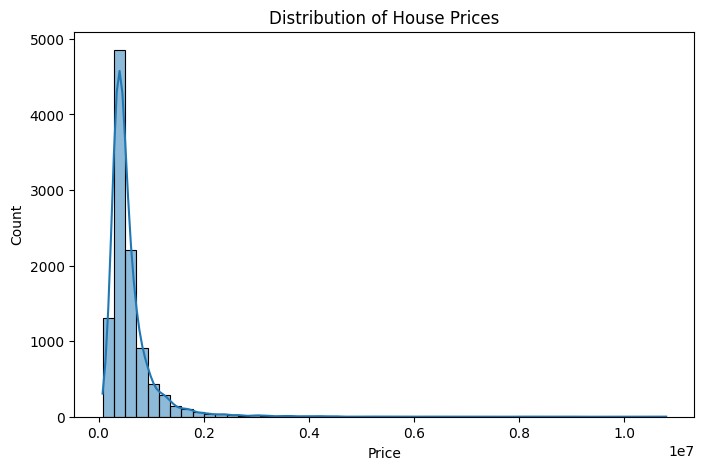

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(y_train, bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.show()

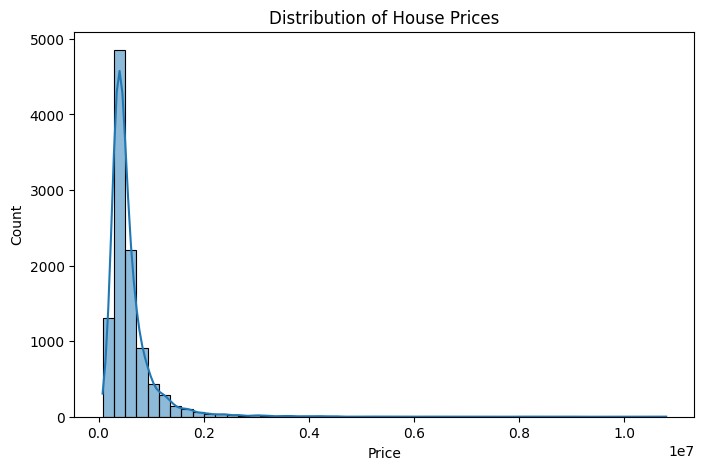

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(y_train, bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.show()

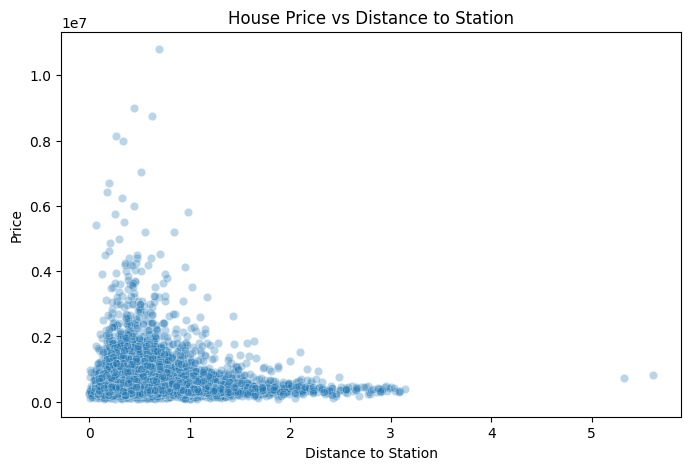

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_train["distance_to_station"], y=y_train, alpha=0.3)
plt.title("House Price vs Distance to Station")
plt.xlabel("Distance to Station")
plt.ylabel("Price")
plt.show()


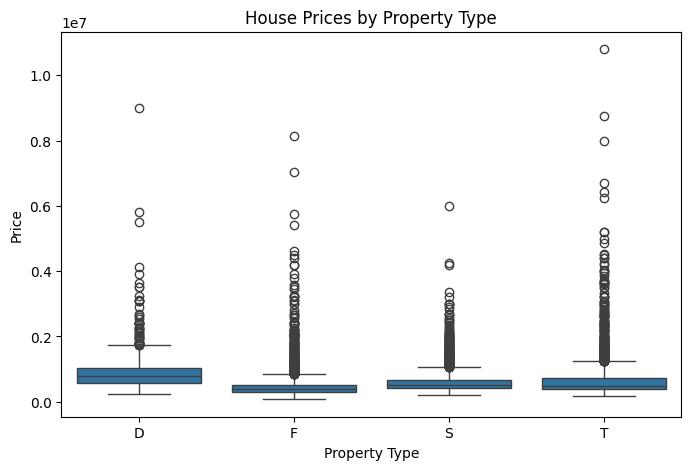

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=X_train["property_type"],
    y=y_train
)
plt.title("House Prices by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price")
plt.show()


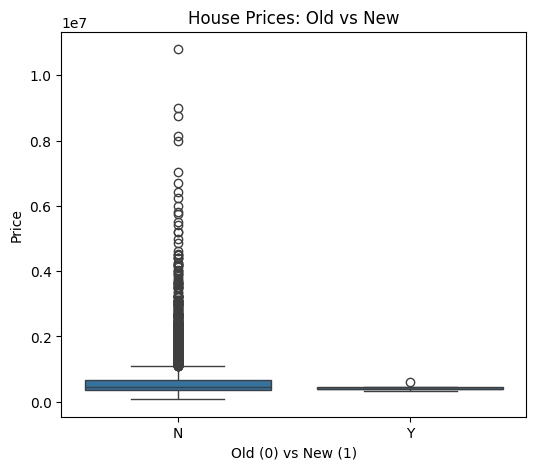

In [9]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x=X_train["whether_old_or_new"],
    y=y_train
)
plt.title("House Prices: Old vs New")
plt.xlabel("Old (0) vs New (1)")
plt.ylabel("Price")
plt.show()


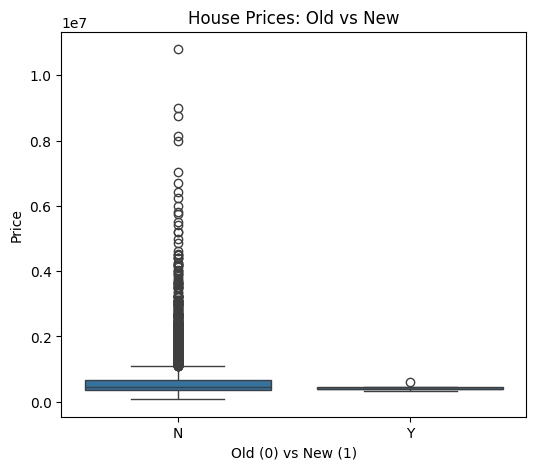

In [10]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x=X_train["whether_old_or_new"],
    y=y_train
)
plt.title("House Prices: Old vs New")
plt.xlabel("Old (0) vs New (1)")
plt.ylabel("Price")
plt.show()


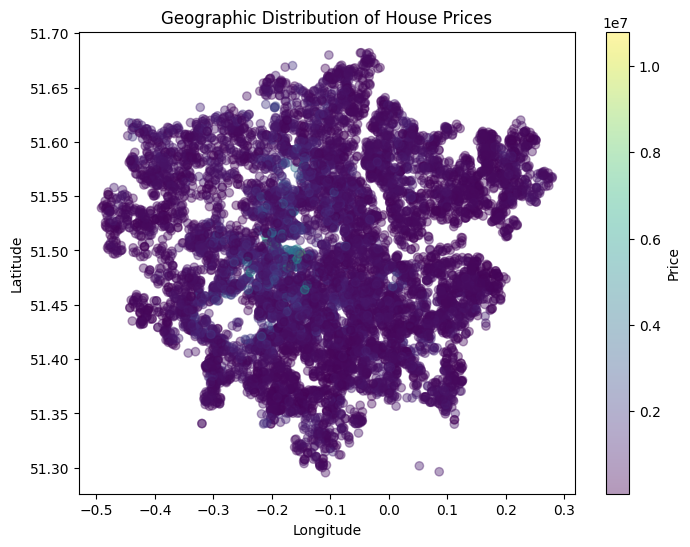

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_train["longitude"],
    X_train["latitude"],
    c=y_train,
    cmap="viridis",
    alpha=0.4
)
plt.colorbar(label="Price")
plt.title("Geographic Distribution of House Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



Estimate a correlation table between prices and other continuous variables. What do you glean from the correlation table?



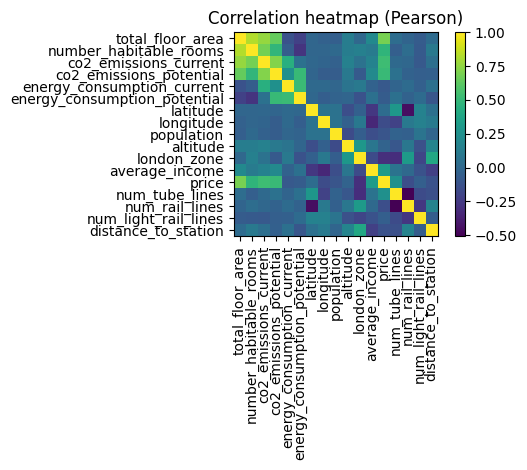

In [12]:
# Compute Pearson correlations for numeric columns (drop non-numeric and ID if present)
df_corr = london_house_prices_2019_training.copy()

if "ID" in df_corr.columns:
    df_corr = df_corr.drop(columns=["ID"])

num_cols = df_corr.select_dtypes(include=[np.number]).columns
corr = df_corr[num_cols].corr(method="pearson")

# Heatmap using matplotlib (no seaborn)
plt.figure()
im = plt.imshow(corr.values, interpolation="nearest")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation heatmap (Pearson)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()





# Fit a linear regression model

To help you get started I build a linear regression model below. I chose a subset of the features with no particular goal. You can (and should) add more variables and/or choose variable selection methods if you want.



## Why I Try Multiple Models

I train several different models because different algorithms capture patterns
in the data in different ways.

By comparing models, I can:
- Check which one predicts prices more accurately
- Reduce the risk of relying on a single method
- Potentially improve performance using model combinations


In [13]:
# -------------------
# Feature definitions
# -------------------
numeric_features = ["distance_to_station", "latitude", "longitude","total_floor_area","number_habitable_rooms"]

categorical_features = [
    "water_company",
    "property_type",
    "whether_old_or_new",
    "freehold_or_leasehold",
    "postcode_short"
]

# -------------------
# Preprocessing
# -------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=2, include_bias=False))
        ]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

# -------------------
# Model pipeline
# -------------------
ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", Ridge())
])

# -------------------
# Log-transform target
# -------------------
y_train_log = np.log(y_train)

# -------------------
# 5-fold cross-validation
# -------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "regressor__alpha": [0.1, 1, 10, 50, 100]
}

ridge_cv = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

ridge_cv.fit(X_train, y_train_log)

print("Best alpha:", ridge_cv.best_params_)
print("Best CV RMSE (log):", -ridge_cv.best_score_)

# -------------------
# Fit final model
# -------------------
best_ridge_model = ridge_cv.best_estimator_
best_ridge_model.fit(X_train, y_train_log)

# -------------------
# Train performance (diagnostic)
# -------------------
y_train_pred = np.exp(best_ridge_model.predict(X_train))
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# -------------------
# Test performance
# -------------------
y_test_pred = np.exp(best_ridge_model.predict(X_test))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train R^2: {train_r2:.3f}")
print(f"Test  RMSE: {test_rmse:.2f}")
print(f"Test  R^2: {test_r2:.3f}")

best_ridge_model


Best alpha: {'regressor__alpha': 0.1}
Best CV RMSE (log): 0.21928526015570596
Train RMSE: 187879.55
Train R^2: 0.859
Test  RMSE: 246692.67
Test  R^2: 0.813


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

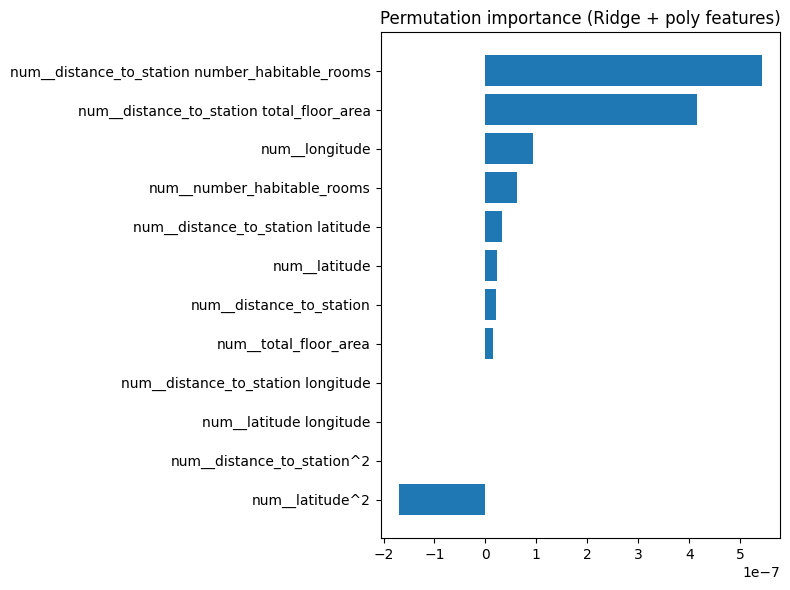

In [14]:

# We'll use permutation importance on the hold-out set
r = permutation_importance(best_ridge_model, X_test, y_test, n_repeats=10, random_state=42)
# Retrieve feature names after preprocessing
feature_names = best_ridge_model.named_steps["preprocess"].get_feature_names_out()

importances = r.importances_mean
order = np.argsort(importances)

importances = r.importances_mean
# Basic bar plot
plt.figure(figsize=(8, 6))
plt.barh(np.array(feature_names)[order], importances[order])
plt.title("Permutation importance (Ridge + poly features)")
plt.tight_layout()
plt.show()


## How I Measure Prediction Quality

I evaluate model performance using two main metrics:

- **RMSE (Root Mean Squared Error)**  
  This measures how far predictions are from the true prices, on average.
  Lower values mean better predictions.

- **R² (R-squared)**  
  This shows how much of the variation in house prices is explained by the model.
  Values closer to 1 indicate better performance.




## Predict the values in testing and out of sample data

Below I use the predict function to test the performance of the model in testing data and summarize the performance of the linear regression model. How can you measure the quality of your predictions?



In [15]:
# Predict on the test split
y_test_pred_log = best_ridge_model.predict(X_test)
y_test_pred = np.exp(y_test_pred_log)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

lr_results = {"RMSE": rmse, "Rsquare": r2}
print("lr_results:", lr_results)
X_oos = london_house_prices_2019_out_of_sample[feature_cols].copy()
X_oos["london_zone"] = X_oos["london_zone"].astype(str)

predictions_oos_log = best_ridge_model.predict(X_oos)
predictions_oos = np.exp(predictions_oos_log)


lr_results: {'RMSE': np.float64(246692.67457367675), 'Rsquare': 0.8131497949993618}




# Fit a tree model

Next I fit a tree model using the same subset of features. Again you can (and should) add more variables and tune the parameter of your tree to find a better fit. 

Compare the performance of the linear regression model with the tree model; which one performs better? Why do you think that is the case?



In [16]:

numeric_features = ["distance_to_station", "latitude", "longitude", "total_floor_area", "number_habitable_rooms"]
categorical_features = ["water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold", "postcode_short" ]

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)



tree_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("regressor", DecisionTreeRegressor(random_state=42))
])


cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "regressor__max_depth": [5, 10, 20, None],
    "regressor__min_samples_leaf": [5, 20, 50, 100]
}

tree_cv = GridSearchCV(
    tree_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

tree_cv.fit(X_train, y_train)

print("Best tree params:", tree_cv.best_params_)
print("Best CV RMSE:", -tree_cv.best_score_)

best_tree_model = tree_cv.best_estimator_
best_tree_model.fit(X_train, y_train)

# Train
y_train_pred = best_tree_model.predict(X_train)
train_rmse_tree = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2_tree = r2_score(y_train, y_train_pred)

# Test
y_test_pred = best_tree_model.predict(X_test)
test_rmse_tree = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2_tree = r2_score(y_test, y_test_pred)

print(f"Tree Train RMSE: {train_rmse_tree:.2f}")
print(f"Tree Train R^2: {train_r2_tree:.3f}")
print(f"Tree Test  RMSE: {test_rmse_tree:.2f}")
print(f"Tree Test  R^2: {test_r2_tree:.3f}")

Best tree params: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 20}
Best CV RMSE: 257706.90566329885
Tree Train RMSE: 213525.52
Tree Train R^2: 0.818
Tree Test  RMSE: 308020.26
Tree Test  R^2: 0.709





# Other algorithms

Use at least two other algorithms to predict prices. Don't forget to tune the parameters of these algorithms. And then compare the performances of your algorithms to linear regression and trees.
Use stacking to ensemble your algorithms.

# Random Forest


In [17]:
from sklearn.ensemble import RandomForestRegressor
numeric_features = ["distance_to_station", "latitude", "longitude", "total_floor_area", "number_habitable_rooms"]
categorical_features = [
    "water_company",
    "property_type",
    "whether_old_or_new",
    "freehold_or_leasehold",
]

preprocess_ohe = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess_ohe),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "regressor__n_estimators": [200, 500],
    "regressor__max_depth": [10, 20, None],
    "regressor__min_samples_leaf": [5, 20, 50]
}

rf_cv = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

rf_cv.fit(X_train, y_train)

print("Random Forest best params:", rf_cv.best_params_)
print("Random Forest best CV RMSE:", -rf_cv.best_score_)

best_rf_model = rf_cv.best_estimator_

# Train performance
rf_train_pred = best_rf_model.predict(X_train)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_r2 = r2_score(y_train, rf_train_pred)

# Test performance
rf_test_pred = best_rf_model.predict(X_test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_r2 = r2_score(y_test, rf_test_pred)

print(f"RF Train RMSE: {rf_train_rmse:.2f}")
print(f"RF Train R^2: {rf_train_r2:.3f}")
print(f"RF Test  RMSE: {rf_test_rmse:.2f}")
print(f"RF Test  R^2: {rf_test_r2:.3f}")


Random Forest best params: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 5, 'regressor__n_estimators': 500}
Random Forest best CV RMSE: 214001.04569174736
RF Train RMSE: 153103.67
RF Train R^2: 0.907
RF Test  RMSE: 287484.23
RF Test  R^2: 0.746


# Graduating Boosting

In [18]:

from sklearn.ensemble import GradientBoostingRegressor

numeric_features = ["distance_to_station", "latitude", "longitude", "total_floor_area", "number_habitable_rooms"]
categorical_features = [
    "water_company",
    "property_type",
    "whether_old_or_new",
    "freehold_or_leasehold",
    "london_zone",          
]
X_train = X_train.copy()
X_test  = X_test.copy()
X_train["london_zone"] = X_train["london_zone"].astype(str)
X_test["london_zone"]  = X_test["london_zone"].astype(str)

preprocess_ohe = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

gb_pipe = Pipeline(steps=[
    ("preprocess", preprocess_ohe),
    ("regressor", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "regressor__n_estimators": [200, 500],
    "regressor__learning_rate": [0.05, 0.1],
    "regressor__max_depth": [2, 3, 4],
    "regressor__min_samples_leaf": [5, 20, 50],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gb_cv = GridSearchCV(
    gb_pipe,
    param_grid=gb_param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

gb_cv.fit(X_train, y_train)

print("Gradient Boosting best params:", gb_cv.best_params_)
print("Gradient Boosting best CV RMSE:", -gb_cv.best_score_)

best_gb_model = gb_cv.best_estimator_

# Train metrics
gb_train_pred = best_gb_model.predict(X_train)
gb_train_rmse = np.sqrt(mean_squared_error(y_train, gb_train_pred))
gb_train_r2 = r2_score(y_train, gb_train_pred)

# Test metrics
gb_test_pred = best_gb_model.predict(X_test)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_test_pred))
gb_test_r2 = r2_score(y_test, gb_test_pred)

print(f"GB Train RMSE: {gb_train_rmse:.2f}")
print(f"GB Train R^2: {gb_train_r2:.3f}")
print(f"GB Test  RMSE: {gb_test_rmse:.2f}")
print(f"GB Test  R^2: {gb_test_r2:.3f}")


Gradient Boosting best params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 4, 'regressor__min_samples_leaf': 5, 'regressor__n_estimators': 500}
Gradient Boosting best CV RMSE: 191276.4761516607
GB Train RMSE: 107475.74
GB Train R^2: 0.954
GB Test  RMSE: 255704.10
GB Test  R^2: 0.799


# Stacking

 Why I Use a Stacking Model

Stacking combines multiple models into a single stronger model.
Each base model learns different patterns, and the final model
learns how to best combine their predictions.

This often leads to better generalization and lower prediction error
than using a single model alone.


In [19]:
from sklearn.ensemble import StackingRegressor

stacking_model = StackingRegressor(
    estimators=[
        ("ridge", best_ridge_model),
        ("rf", best_rf_model),
        ("gb", best_gb_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=cv,
    n_jobs=-1
)
stack_cv_rmse = (-1 * cross_val_score(
    stacking_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)).mean()

print(f"Stacking CV RMSE: {stack_cv_rmse:.2f}")

stacking_model.fit(X_train, y_train)

stack_train_pred = stacking_model.predict(X_train)
stack_train_rmse = np.sqrt(mean_squared_error(y_train, stack_train_pred))
stack_train_r2 = r2_score(y_train, stack_train_pred)

print(f"Stack Train RMSE: {stack_train_rmse:.2f}")
print(f"Stack Train R^2: {stack_train_r2:.3f}")

stack_test_pred = stacking_model.predict(X_test)
stack_test_rmse = np.sqrt(mean_squared_error(y_test, stack_test_pred))
stack_test_r2 = r2_score(y_test, stack_test_pred)

print(f"Stack Test RMSE: {stack_test_rmse:.2f}")
print(f"Stack Test R^2: {stack_test_r2:.3f}")


Stacking CV RMSE: 186794.07
Stack Train RMSE: 115124.35
Stack Train R^2: 0.947
Stack Test RMSE: 251228.09
Stack Test R^2: 0.806


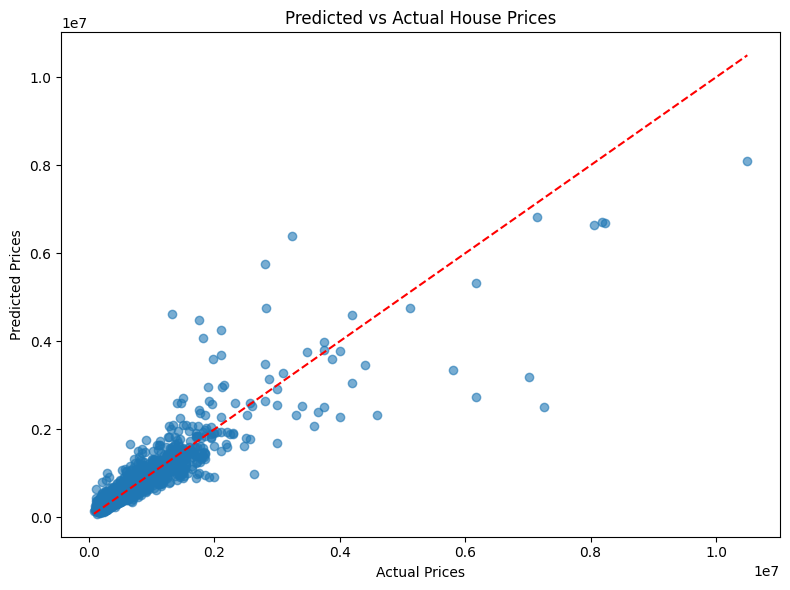

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, stack_test_pred, alpha=0.6)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")

plt.tight_layout()
plt.savefig("predicted_vs_actual.png")

plt.show()




# Pick investments

In this section you should use the best algorithm you identified to choose 200 properties from the out of sample data.



Out-of-Sample Predictions

I now apply the final stacking model to the out-of-sample dataset.
These properties were not used during training, so this simulates
a real-world prediction scenario.


Investment Selection Logic

After predicting prices for all out-of-sample properties:
- I sort properties by predicted price (highest first)
- I select the top 200 properties
- These are marked as investment opportunities (`buy = 1`)

All remaining properties are marked as `buy = 0`.


In [ ]:
# Pick investments & create submission

numchoose = 200

# Copy OOS data
oos = london_house_prices_2019_out_of_sample.copy()

# Use the SAME feature columns as training
X_oos = oos[feature_cols].copy()
X_oos["london_zone"] = X_oos["london_zone"].astype(str)

# Predict using FINAL stacking model
oos["predict"] = stacking_model.predict(X_oos)

# Choose top 200 predicted prices
oos = oos.sort_values(by="predict", ascending=False)
oos["buy"] = 0
oos.iloc[:numchoose, oos.columns.get_loc("buy")] = 1

# Safety check
assert oos["buy"].sum() == numchoose

# Export
oos[["predict", "buy"]].to_csv("Galusca_Andreea.csv", index=False)

print("Wrote Galusca_Andreea.csv")


Wrote Galusca_Andreea.csv


## Appendix — Original Rmd (verbatim)

```rmd
---
title: 'Session 10: Data Science Capstone Project'
author: "Dr Kanishka Bhattacharya"
date: "`r Sys.Date()`"
output: 
    html_document:
      number_sections: true
      highlight: haddock
      theme: spacelab
      toc: yes
      toc_depth: 2
      toc_float:
        collapsed: false
---

```{r setup, include=FALSE}
knitr::opts_chunk$set(echo = TRUE)
```

<style>
div.navy1 { background-color:#686868; border-radius: 5px; padding: 20px; border-style: groove; color: #ffffff;}

</style>



```{r, load_libraries, include = FALSE}

if(!is.element("tidyverse", installed.packages()[,1]))
{  install.packages("tidyverse", repos = "http://cran.us.r-project.org")}

if(!is.element("Hmisc", installed.packages()[,1]))
{  install.packages("Hmisc", repos = "http://cran.us.r-project.org")} #package for data summary using `describe`

if(!is.element("ggplot2", installed.packages()[,1]))
{  install.packages("ggplot2", repos = "http://cran.us.r-project.org")} #package for plots
if(!is.element("ggthemes", installed.packages()[,1]))
{  install.packages("ggthemes", repos = "http://cran.us.r-project.org")} #package to make fancier ggplots

if(!is.element("janitor", installed.packages()[,1]))
{ install.packages("janitor", repos = "http://cran.us.r-project.org")} #package to visualize results of machine learning tools
if(!is.element("rpart.plot", installed.packages()[,1]))
{  install.packages("rpart.plot", repos = "http://cran.us.r-project.org")} #package to visualize trees

library(rpart.plot)
library(caret)
library(tidyverse) # the usual stuff: dplyr, readr, and other goodies
library(lubridate)
library(janitor) # clean_names()
library(Hmisc)
```

# Introduction and learning objectives

<div class = "navy1">
The purpose of this exercise is to build an estimation engine to guide investment decisions in London house market. You will first build machine learning algorithms (and tune them) to estimate the house prices given variety of information about each property. Then, using your algorithm, you will choose 200 houses to invest in out of about 2000 houses on the market at the moment.


<b>Learning objectives</b>
 
<ol type="i">
  <li>Using different data mining algorithms for prediction.</li>
  <li>Dealing with large data sets</li>
  <li>Tuning data mining algorithms</li>
  <li>Interpreting data mining algorithms and deducing importance of variables</li>
  <li>Using results of data mining algorithms to make business decisions</li>
</ol>  
</div>

# Load data

There are two sets of data, i) training data that has the actual prices ii) out of sample data that has the asking prices. Load both data sets. 

Make sure you understand what information each column contains. Note that not all information provided might be useful in predicting house prices, but do not make any assumptions before you decide what information you use in your prediction algorithms.

```{r read-investigate}
#read in the data

london_house_prices_2019_training<-read.csv("training_data_assignment_with_prices.csv")
london_house_prices_2019_out_of_sample<-read.csv("test_data_assignment.csv")



#fix data types in both data sets

#fix dates
london_house_prices_2019_training <- london_house_prices_2019_training %>% mutate(date=as.Date(date))
london_house_prices_2019_out_of_sample<-london_house_prices_2019_out_of_sample %>% mutate(date=as.Date(date))
#change characters to factors
london_house_prices_2019_training <- london_house_prices_2019_training %>% mutate_if(is.character,as.factor)
london_house_prices_2019_out_of_sample<-london_house_prices_2019_out_of_sample %>% mutate_if(is.character,as.factor)

#take a quick look at what's in the data
str(london_house_prices_2019_training)
str(london_house_prices_2019_out_of_sample)



```


```{r split the price data to training and testing}
#let's do the initial split
library(rsample)
train_test_split <- initial_split(london_house_prices_2019_training, prop = 0.75) #training set contains 75% of the data
# Create the training dataset
train_data <- training(train_test_split)
test_data <- testing(train_test_split)



```


# Visualize data 

Visualize and examine the data. What plots could be useful here? What do you learn from these visualizations?

```{r visualize}




```

Estimate a correlation table between prices and other continuous variables. What do you glean from the correlation table?

```{r, correlation table, warning=FALSE, message=FALSE}

# produce a correlation table using GGally::ggcor()
# this takes a while to plot

library("GGally")
london_house_prices_2019_training %>% 
  select(-ID) %>% #keep Y variable last
  ggcorr(method = c("pairwise", "pearson"), layout.exp = 2,label_round=2, label = TRUE,label_size = 2,hjust = 1,nbreaks = 5,size = 2,angle = -20)

```


# Fit a linear regression model

To help you get started I build a linear regression model below. I chose a subset of the features with no particular goal. You can (and should) add more variables and/or choose variable selection methods if you want.

```{r LR model}


#Define control variables
control <- trainControl (
    method="cv",
    number=5,
    verboseIter=TRUE) #by setting this to true the model will report its progress after each estimation

#we are going to train the model and report the results using k-fold cross validation
model1_lm<-train(
    price ~ distance_to_station +water_company+property_type+whether_old_or_new+freehold_or_leasehold+latitude+ longitude,
    train_data,
   method = "lm",
    trControl = control
   )

# summary of the results
summary(model1_lm)
```


```{r}
# we can check variable importance as well
importance <- varImp(model1_lm, scale=TRUE)
plot(importance)


```

## Predict the values in testing and out of sample data

Below I use the predict function to test the performance of the model in testing data and summarize the performance of the linear regression model. How can you measure the quality of your predictions?

```{r}
# We can predict the testing values

predictions <- predict(model1_lm,test_data)

lr_results<-data.frame(  RMSE = RMSE(predictions, test_data$price), 
                            Rsquare = R2(predictions, test_data$price))

                            
lr_results                         

#We can predict prices for out of sample data the same way
predictions_oos <- predict(model1_lm,london_house_prices_2019_out_of_sample)
```

# Fit a tree model

Next I fit a tree model using the same subset of features. Again you can (and should) add more variables and tune the parameter of your tree to find a better fit. 

Compare the performance of the linear regression model with the tree model; which one performs better? Why do you think that is the case?

```{r tree model}

model2_tree <- train(
  price ~ distance_to_station +water_company+property_type+whether_old_or_new+latitude+ longitude,
  train_data,
  method = "rpart",
  trControl = control,
  tuneLength=10
    )

#You can view how the tree performs
model2_tree$results

#You can view the final tree
rpart.plot(model2_tree$finalModel)

#you can also visualize the variable importance
importance <- varImp(model2_tree, scale=TRUE)
plot(importance)

```


# Other algorithms

Use at least two other algorithms to predict prices. Don't forget to tune the parameters of these algorithms. And then compare the performances of your algorithms to linear regression and trees.

# Stacking

Use stacking to ensemble your algorithms.

```{r,warning=FALSE,  message=FALSE }


```


# Pick investments

In this section you should use the best algorithm you identified to choose 200 properties from the out of sample data.

```{r,warning=FALSE,  message=FALSE }


numchoose=200

oos<-london_house_prices_2019_out_of_sample

#predict the value of houses
oos$predict <- predict(model2_tree,oos)
#Choose the ones you want to invest here
#Make sure you choose exactly 200 of them

#output your choices. Change the name of the file to your "lastname_firstname.csv"
write.csv(oos,"my_submission.csv")

```

```